In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import PartialDependenceDisplay
import seaborn as sns

In [106]:
# 1. Load & clean
df = pd.read_excel("LEGO Analytics Case Data.xlsx")
df = df.rename(columns={
    'Set #':               'SetID',
    'Piece Count':         'PieceCount',
    '# of Minifigures':    'Minifigures',
    'US Retail Price ($)': 'Price'
})
df['price_per_piece'] = df['Price'] / df['PieceCount']
# check for missing data in your numeric features
numeric_features = ['PieceCount','Minifigures','Weight (lb.)',
                    'Length (in.)','Width (in.)','Height (in.)']
assert df[numeric_features].isnull().sum().sum() == 0, "Missing numeric data!"

In [107]:
# 2. Price‐range we are loking at
bins   = [0, 29.99, 69.99, 99.99, np.inf]
labels = ['19.99–29.99', '34.99–69.99', '74.99–99.99', '100+']

df['PriceRange'] = pd.cut(
    df['Price'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [108]:
# 3. Features & target
numeric_features     = ['PieceCount','Minifigures','Weight (lb.)','Length (in.)','Width (in.)','Height (in.)']
categorical_features = ['Theme','Subtheme','PriceRange']
X = df[numeric_features + categorical_features]
y = df['Price']

In [109]:
# 4. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

In [110]:
# 5. Preprocessor
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

In [111]:
# 6. Pipelines
lr_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', LinearRegression())
])
rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

In [112]:
# 7. 5‐fold CV on TRAIN only
n_splits = min(5, len(X_train))
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
scoring = {'r2':'r2', 'neg_mse':'neg_mean_squared_error'}
cv_lr = cross_validate(lr_pipeline, X_train, y_train, cv=kf, scoring=scoring)
cv_rf = cross_validate(rf_pipeline, X_train, y_train, cv=kf, scoring=scoring)

def summarize(cv_res, name):
    r2s   = cv_res['test_r2']
    rmses = np.sqrt(-cv_res['test_neg_mse'])
    return {
        'Model':     name,
        'R2 Mean':   r2s.mean(),
        'R2 Std':    r2s.std(),
        'RMSE Mean': rmses.mean(),
        'RMSE Std':  rmses.std()
    }

cv_summary = pd.DataFrame([
    summarize(cv_lr, 'Linear Regression'),
    summarize(cv_rf, 'Random Forest')
])
print("CV Summary:\n", cv_summary)

CV Summary:
                Model   R2 Mean    R2 Std  RMSE Mean  RMSE Std
0  Linear Regression  0.948195  0.020609  11.925402  3.522269
1      Random Forest  0.906819  0.027572  16.665432  5.309110


In [113]:
# 8. Fit on TRAIN and evaluate on TEST
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

test_metrics = pd.DataFrame({
    'Model':     ['Linear Regression','Random Forest'],
    'Test R2':   [r2_score(y_test, y_pred_lr), r2_score(y_test, y_pred_rf)],
    'Test RMSE': [np.sqrt(mean_squared_error(y_test, y_pred_lr)),
                  np.sqrt(mean_squared_error(y_test, y_pred_rf))]
})
print("\nTest Metrics:\n", test_metrics)


Test Metrics:
                Model   Test R2  Test RMSE
0  Linear Regression  0.950323  10.156166
1      Random Forest  0.957275   9.418788


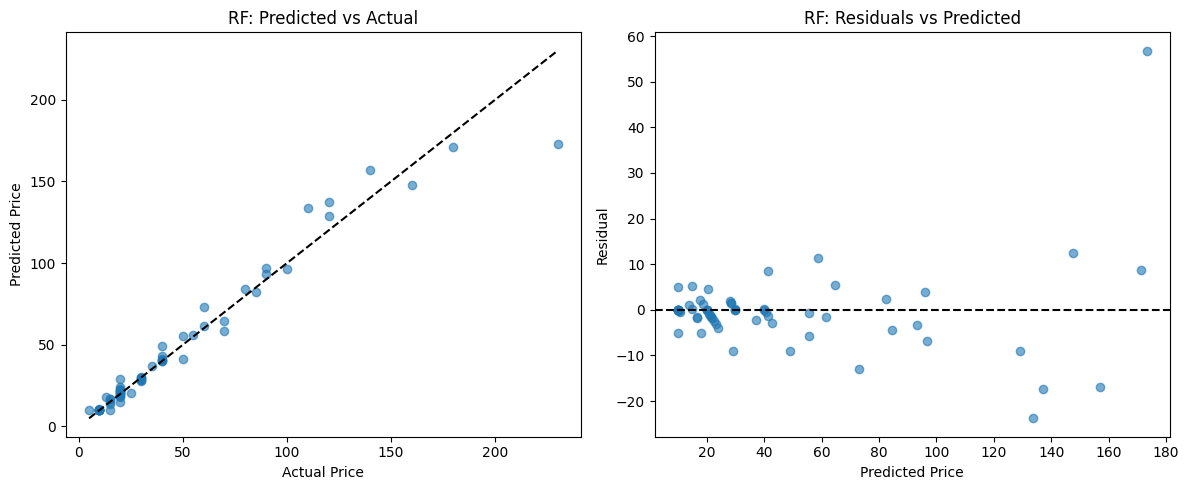

In [114]:
# 9. Predicted vs Actual & Residuals (RF)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(y_test, y_pred_rf, alpha=0.6)
lims = [min(y_test.min(),y_pred_rf.min()), max(y_test.max(),y_pred_rf.max())]
plt.plot(lims, lims, 'k--')
plt.xlabel("Actual Price"); plt.ylabel("Predicted Price")
plt.title("RF: Predicted vs Actual")

plt.subplot(1,2,2)
resid = y_test - y_pred_rf
plt.scatter(y_pred_rf, resid, alpha=0.6)
plt.axhline(0, linestyle='--', color='k')
plt.xlabel("Predicted Price"); plt.ylabel("Residual")
plt.title("RF: Residuals vs Predicted")

plt.tight_layout()
plt.show()

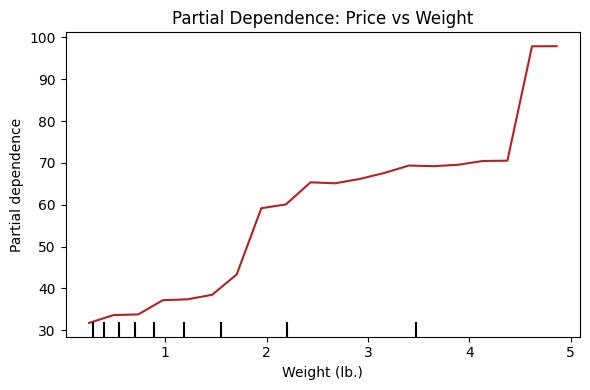

In [90]:
# 10. Partial Dependence on Weight (lb.)
fig, ax = plt.subplots(figsize=(6,4))
PartialDependenceDisplay.from_estimator(
    rf_pipeline, X_train, ['Weight (lb.)'],
    kind='average', grid_resolution=20,
    line_kw={'color':'firebrick'}, ax=ax
)
ax.set_title("Partial Dependence: Price vs Weight")
plt.tight_layout()
plt.show()

In [91]:
# Cross-Validation Performance
cv = pd.read_csv('cv_performance_comparison-Copy1.csv')

# R² bar chart
plt.figure(figsize=(6, 4))
x = np.arange(len(cv))
plt.bar(x, cv['R2 Mean'], yerr=cv['R2 Std'], capsize=5)
plt.xticks(x, cv['Model'])
plt.ylabel('R² Mean')
plt.title('Cross-Validation R² Comparison')
plt.tight_layout()
plt.savefig('cv_r2_comparison.png')
plt.close()

# RMSE bar chart
plt.figure(figsize=(6, 4))
plt.bar(x, cv['RMSE Mean'], yerr=cv['RMSE Std'], capsize=5, color='tab:orange')
plt.xticks(x, cv['Model'])
plt.ylabel('RMSE Mean (USD)')
plt.title('Cross-Validation RMSE Comparison')
plt.tight_layout()
plt.savefig('cv_rmse_comparison.png')
plt.close()

# Random Forest Feature Importances

feat_imp = pd.read_csv('rf_feature_importances-Copy1.csv')

plt.figure(figsize=(8, 6))
top10 = feat_imp.head(10)
sns.barplot(x='Importance', y='Feature', data=top10, orient='h')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('rf_top10_features.png')
plt.close()


# Value-Potential Top/Bottom by PriceRange

vp = pd.read_csv('value_potential_top_bottom-Copy1.csv')

# Build a Top/Bottom 2 subset per PriceRange
dfs = []
for pr_label, grp in vp.groupby('PriceRange'):
    # sort by ValuePotential
    grp_sorted = grp.sort_values('ValuePotential')
    bottom2 = grp_sorted.head(2).copy()
    bottom2['Position'] = 'Bottom 2'
    top2    = grp_sorted.tail(2).copy()
    top2['Position']    = 'Top 2'
    bottom2['PriceRange'] = pr_label
    top2['PriceRange']    = pr_label
    dfs.append(bottom2)
    dfs.append(top2)

vp_tb = pd.concat(dfs)

# Now plot
plt.figure(figsize=(8, 6))
sns.barplot(
    x='ValuePotential',
    y='PriceRange',
    hue='Position',
    data=vp_tb,
    dodge=True
)
plt.title('Value Potential – Top/Bottom 2 by Price Range')
plt.xlabel('Value Potential (USD)')
plt.ylabel('Price Range')
plt.legend(title='Position', loc='lower right')
plt.tight_layout()
plt.savefig('value_potential_by_pricerange.png')
plt.close()